In [39]:
!pip install vaderSentiment
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
analyzer = SentimentIntensityAnalyzer()

https://vadersentiment.readthedocs.io/en/latest/

In [35]:
import numpy as np
import pandas as pd
df = pd.read_csv('reviews_schools.csv', index_col=0)
df = df.reset_index(drop=True)
df['reviews'] = df['reviews'].apply(lambda x: x.split('ЮРА'))
df_rev = df.explode('reviews')
df_rev = df_rev.reset_index(drop=True)
df_rev

,geo_id,neighborhood_city,links,status,reviews
0,9cd7eab982c5c35bcd6f05d732d333c5,"Price End, North Port",https://www.greatschools.org//florida/north-po...,Success,They searched me everyday for the last 5 days ...
1,9cd7eab982c5c35bcd6f05d732d333c5,"Price End, North Port",https://www.greatschools.org//florida/north-po...,Success,We just moved here from Orlando and from day o...
2,9cd7eab982c5c35bcd6f05d732d333c5,"Price End, North Port",https://www.greatschools.org//florida/north-po...,Success,Between administration and the constant studen...
3,9cd7eab982c5c35bcd6f05d732d333c5,"Price End, North Port",https://www.greatschools.org//florida/north-po...,Success,"All American suburbian school, lots of program..."
4,9cd7eab982c5c35bcd6f05d732d333c5,"Price End, North Port",https://www.greatschools.org//florida/north-po...,Success,Don’t learn a lot of things but the things tha...
...,...,...,...,...,...
121565,748b3444fcd67399ce7da7b6fd003935,"College Hill, Wichita",https://www.greatschools.org//kansas/wichita/1...,Success,school was horrific with roaches everywhere. w...
121566,748b3444fcd67399ce7da7b6fd003935,"College Hill, Wichita",https://www.greatschools.org//kansas/wichita/1...,Success,they give so much homework and don’t even expl...
121567,748b3444fcd67399ce7da7b6fd003935,"College Hill, Wichita",https://www.greatschools.org//kansas/wichita/1...,Success,little to none of the students actually care a...
121568,748b3444fcd67399ce7da7b6fd003935,"College Hill, Wichita",https://www.greatschools.org//kansas/wichita/1...,Success,I had my Daughter at this school and was amaze...


In [41]:
s = []
for i,j in df_rev.iterrows():
 scores = analyzer.polarity_scores(j['reviews'])
 s.append(scores['compound'])
df_rev['sent_pos'] = s

compound score вычисляется путем суммирования оценок каждого слова в лексиконе, скорректированных в соответствии с правилами, а затем нормализуется до значения от -1 (максимально негативный) до +1 (максимально позитивный). - из документации

In [50]:
df_sentiments_by_neighbourhoods = df_rev.groupby('geo_id')['sent_pos'].mean().reset_index()

In [53]:
df_sentiments_by_neighbourhoods.to_csv('df_sentiments_by_neighbourhoods.csv')
df_sentiments_by_neighbourhoods

,geo_id,sent_pos
0,00005aa5580541fd3360931f76a100e6,0.471771
1,0009d1b5622f7277227b010855301de4,0.523243
2,00186f7524e7e141338f3d907193d92c,0.469488
3,00250d4ac20c2bfd6bd34d1014b36f91,0.232129
4,00272d5cc0e75e6fb6ee6ea99346b53a,0.151863
...,...,...
4164,ff9d94030bd7d32145a1fc841dec80f2,0.235591
4165,ffac65743902b59f0925ec7b9669fd35,0.304656
4166,ffae5e39d095b2a1e856088d1acfdf2d,0.688150
4167,ffaffaab65f88db1a827a3e5e533b4a6,0.164223


<Axes: ylabel='Frequency'>

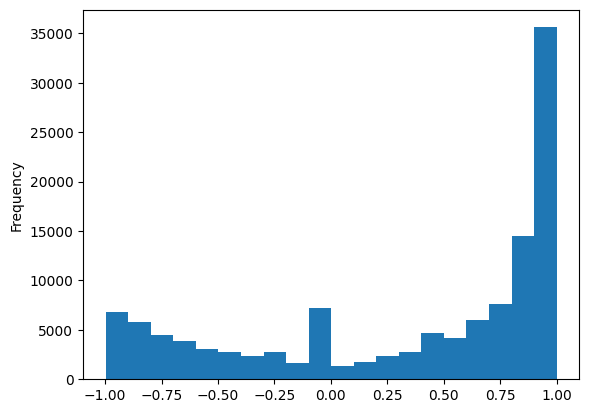

In [57]:
df_rev['sent_pos'].plot(kind='hist',bins=20)

<Axes: ylabel='Frequency'>

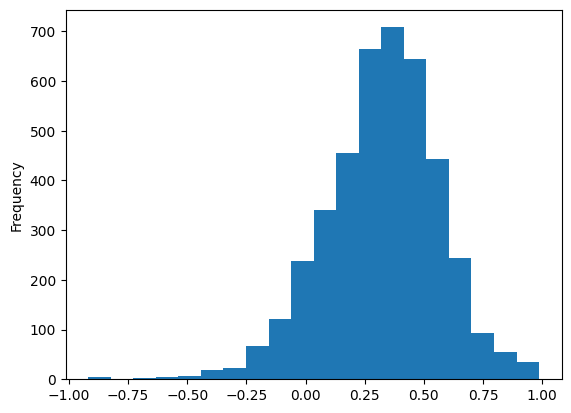

In [55]:
df_sentiments_by_neighbourhoods['sent_pos'].plot(kind='hist',bins=20)